# Hotel price prediction

## Import the file and read it

In [7]:
import pandas as pd
import os

In [8]:
df = pd.read_csv("../../notebook/Merge/final_selected_data.csv", low_memory=False)
df

,room_type_id,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,...,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,hotel_id,room_room_type_name,hotel_name,hotel_address,region
0,1,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,71897952,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,"73 Đoàn Thị Điểm, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
1,2,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,49685029,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
2,3,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,49685029,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
3,4,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,65481766,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),"QL51, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
4,5,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,5808626,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,"Số 328C, Đại lộ B nh Dương, Khu phố Hưng Lộc, ...",Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19515,12043,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,80986701,Phòng Tiêu Chuẩn (Standard Room),Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19516,12044,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,80986701,Deluxe - 1 Bedroom Apartment Magnificent views,Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19517,12045,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,80986701,Deluxe giường đôi hoặc 2 giường (Deluxe Double...,Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19518,12046,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,81051270,Phòng Gia Đình (Family Room),Hotel Thu Trang,Hotel thu trang số 11 ngõ 63 đường phạm hùng p...,Tuyên Quang


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19520 entries, 0 to 19519
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   room_type_id                  19520 non-null  int64  
 1   large_double_bed              19520 non-null  int64  
 2   large_bed                     19520 non-null  int64  
 3   single_bed                    19520 non-null  int64  
 4   sofa_bed                      19520 non-null  int64  
 5   double_bed                    19520 non-null  int64  
 6   small_double_bed              19520 non-null  int64  
 7   king_size_bed                 19520 non-null  int64  
 8   futon_mattress                19520 non-null  int64  
 9   bunk_bed                      19520 non-null  int64  
 10  flexibility_score             19520 non-null  int64  
 11  sqm                           18054 non-null  float64
 12  bathroom_count                19520 non-null  int64  
 13  i

In [10]:
df.shape

(19520, 51)

In [11]:
df.drop(columns=["room_type_id","hotel_id","hotel_address"], inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19520 entries, 0 to 19519
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              19520 non-null  int64  
 1   large_bed                     19520 non-null  int64  
 2   single_bed                    19520 non-null  int64  
 3   sofa_bed                      19520 non-null  int64  
 4   double_bed                    19520 non-null  int64  
 5   small_double_bed              19520 non-null  int64  
 6   king_size_bed                 19520 non-null  int64  
 7   futon_mattress                19520 non-null  int64  
 8   bunk_bed                      19520 non-null  int64  
 9   flexibility_score             19520 non-null  int64  
 10  sqm                           18054 non-null  float64
 11  bathroom_count                19520 non-null  int64  
 12  is_private_bathroom           19520 non-null  int64  
 13  v

In [13]:
df

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,room_room_type_name,hotel_name,region
0,1,0,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,Bà Rịa
1,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),Bà Rịa
4,1,0,1,0,0,0,0,0,0,2,...,0,0,1,0,0,0,0,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19515,0,0,1,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Tiêu Chuẩn (Standard Room),Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19516,0,0,1,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Deluxe - 1 Bedroom Apartment Magnificent views,Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19517,0,0,0,0,1,0,0,0,0,2,...,1,0,1,0,1,0,0,Deluxe giường đôi hoặc 2 giường (Deluxe Double...,Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19518,1,0,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Gia Đình (Family Room),Hotel Thu Trang,Tuyên Quang


In [14]:
df.describe()

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,price_option_price,adults_number,children_number,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng
count,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,...,1.949100e+04,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000
mean,0.363832,0.245389,0.227203,0.053535,0.240369,0.011373,0.025615,0.010553,0.013678,1.050820,...,1.567054e+06,2.473412,0.466035,0.650973,0.105123,0.734682,0.218699,0.414652,0.030482,0.177459
std,0.481113,0.430329,0.419035,0.225103,0.427318,0.106039,0.157987,0.102188,0.116155,0.224252,...,5.910918e+06,1.753879,0.720954,0.476675,0.306720,0.441513,0.413374,0.492674,0.171913,0.382066
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,4.335440e+05,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,7.352940e+05,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.396832e+06,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,...,6.666667e+08,50.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df.shape

(19520, 48)

## Check data quality

In [16]:
df.isna().sum()

large_double_bed                   0
large_bed                          0
single_bed                         0
sofa_bed                           0
double_bed                         0
small_double_bed                   0
king_size_bed                      0
futon_mattress                     0
bunk_bed                           0
flexibility_score                  0
sqm                             1466
bathroom_count                     0
is_private_bathroom                0
views                              0
balcony-terrace                    0
closet                             0
air_conditioning                   0
hair_dryer                         0
complimentary-bottled-water        0
bathtub                            0
shower                             0
refrigerator                       0
high-floor                         0
dressing-room                      0
ground-floor                       0
private-pool                       0
top-floor                          0
c

In [17]:
df = df.dropna(subset=['price_option_price'])

In [18]:
df = df.dropna(subset=['sqm'])

In [19]:
df.isna().sum()

large_double_bed                0
large_bed                       0
single_bed                      0
sofa_bed                        0
double_bed                      0
small_double_bed                0
king_size_bed                   0
futon_mattress                  0
bunk_bed                        0
flexibility_score               0
sqm                             0
bathroom_count                  0
is_private_bathroom             0
views                           0
balcony-terrace                 0
closet                          0
air_conditioning                0
hair_dryer                      0
complimentary-bottled-water     0
bathtub                         0
shower                          0
refrigerator                    0
high-floor                      0
dressing-room                   0
ground-floor                    0
private-pool                    0
top-floor                       0
complimentary-instant-coffee    0
electric-blanket                0
free-welcome-d

In [20]:
df.shape

(18026, 48)

In [21]:
df.duplicated().sum()

86

In [22]:
df = df.drop_duplicates()

In [23]:
df.shape

(17940, 48)

## EDA: Single feature

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17940 entries, 0 to 19519
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              17940 non-null  int64  
 1   large_bed                     17940 non-null  int64  
 2   single_bed                    17940 non-null  int64  
 3   sofa_bed                      17940 non-null  int64  
 4   double_bed                    17940 non-null  int64  
 5   small_double_bed              17940 non-null  int64  
 6   king_size_bed                 17940 non-null  int64  
 7   futon_mattress                17940 non-null  int64  
 8   bunk_bed                      17940 non-null  int64  
 9   flexibility_score             17940 non-null  int64  
 10  sqm                           17940 non-null  float64
 11  bathroom_count                17940 non-null  int64  
 12  is_private_bathroom           17940 non-null  int64  
 13  views 

Flexibility Score (Bed Configuration Feature)

flexibility_score represents the level of uncertainty or flexibility in a room’s bed configuration.
While individual bed-type columns (e.g., single bed, double bed, king bed) indicate which bed types may be available, the flexibility score captures how many alternative bed arrangements are possible for that room.

For example:

flex = 1 suggests a fixed and clearly specified bed setup.

flex = 2 indicates multiple possible arrangements (e.g., two single beds OR one double bed).

flex = 3 means the bed configuration is more ambiguous, allowing even more alternatives.

Therefore, this feature is treated as an ordinal indicator of bed-layout ambiguity rather than a continuous numeric variable.

In [25]:
cat_col = ['views', 'room_room_type_name', 'region']

num_col = ['sqm', 'bathroom_count', 'bedroom_count', 'adults_number', 'children_number', 'flexibility_score', 'price_option_price']

bin_col = [c for c in df.columns 
           if c not in cat_col + num_col] 


### Numerical feature

In [26]:
num_col

['sqm',
 'bathroom_count',
 'bedroom_count',
 'adults_number',
 'children_number',
 'flexibility_score',
 'price_option_price']

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
sqm,17940.0,4.144041e+01,9.240813e+01,3.0,22.00,30.0,40.0,6000.0
bathroom_count,17940.0,9.643255e-01,8.958585e-01,0.0,1.00,1.0,1.0,21.0
bedroom_count,17940.0,2.389075e-01,9.067708e-01,0.0,0.00,0.0,0.0,21.0
adults_number,17940.0,2.413099e+00,1.525076e+00,1.0,2.00,2.0,2.0,50.0
children_number,17940.0,4.668896e-01,6.866218e-01,0.0,0.00,0.0,1.0,12.0
flexibility_score,17940.0,1.054013e+00,2.309298e-01,1.0,1.00,1.0,1.0,5.0
price_option_price,17940.0,1.441629e+06,5.682715e+06,307.0,438728.75,738443.0,1378485.5,666666667.0


In [29]:
stats = df[num_col].describe().T
stats['skew'] = df[num_col].skew()
stats['kurtosis'] = df[num_col].kurtosis()
stats.sort_values('skew', ascending=False)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
price_option_price,17940.0,1.441629e+06,5.682715e+06,307.0,438728.75,738443.0,1378485.5,666666667.0,91.916574,10532.200116
sqm,17940.0,4.144041e+01,9.240813e+01,3.0,22.00,30.0,40.0,6000.0,31.729749,1519.880851
adults_number,17940.0,2.413099e+00,1.525076e+00,1.0,2.00,2.0,2.0,50.0,9.700275,178.086960
bedroom_count,17940.0,2.389075e-01,9.067708e-01,0.0,0.00,0.0,0.0,21.0,7.543000,99.416244
bathroom_count,17940.0,9.643255e-01,8.958585e-01,0.0,1.00,1.0,1.0,21.0,7.316130,108.193694
flexibility_score,17940.0,1.054013e+00,2.309298e-01,1.0,1.00,1.0,1.0,5.0,4.323988,20.405962
children_number,17940.0,4.668896e-01,6.866218e-01,0.0,0.00,0.0,1.0,12.0,2.392596,15.339653


From `describe()` statistics and the skewness/kurtosis analysis, most numerical variables are **right-skewed** and contain **extreme outliers**, especially the target variable `price_option_price`.

**Key observations**
- **`price_option_price`** shows an extremely heavy long-tail distribution  
  - Median ≈ **738k**, while mean ≈ **1.44M**, indicating strong influence from outliers  
  - Max ≈ **666,666,667** (very likely abnormal / rare cases)  
  - Skewness ≈ **91.9** and kurtosis ≈ **10532**, confirming severe outliers.
- **`sqm`** is also highly skewed  
  - Typical room size is around **20–40 m²**, but max reaches **6000 m²**, which is unrealistic  
  - Skewness ≈ **31.7**, kurtosis ≈ **1520**, indicating strong outliers.
- **`adults_number`** is mostly **2**, but contains extreme values (max = **50**), suggesting possible noise or non-standard room types.
- **`bathroom_count`** is mostly **1**, but includes rare high counts (max = **21**), likely villas/apartments or errors.
- **`bedroom_count`** is mostly **0** (typical for hotel rooms), but large values (max = **21**) indicate villa/apartment listings.
- **`flexibility_score`** has low variance (mostly **1**), suggesting most rooms have a fixed bed configuration.
- **`children_number`** is mostly **0–1**, with a few outliers (max = **12**).

**Conclusion:**  
For robust analysis/modeling, it is recommended to apply **log transformation** to the target (`log1p(price_option_price)`) and consider **outlier clipping** for highly skewed features such as `price_option_price`, `sqm`, and `adults_number`.


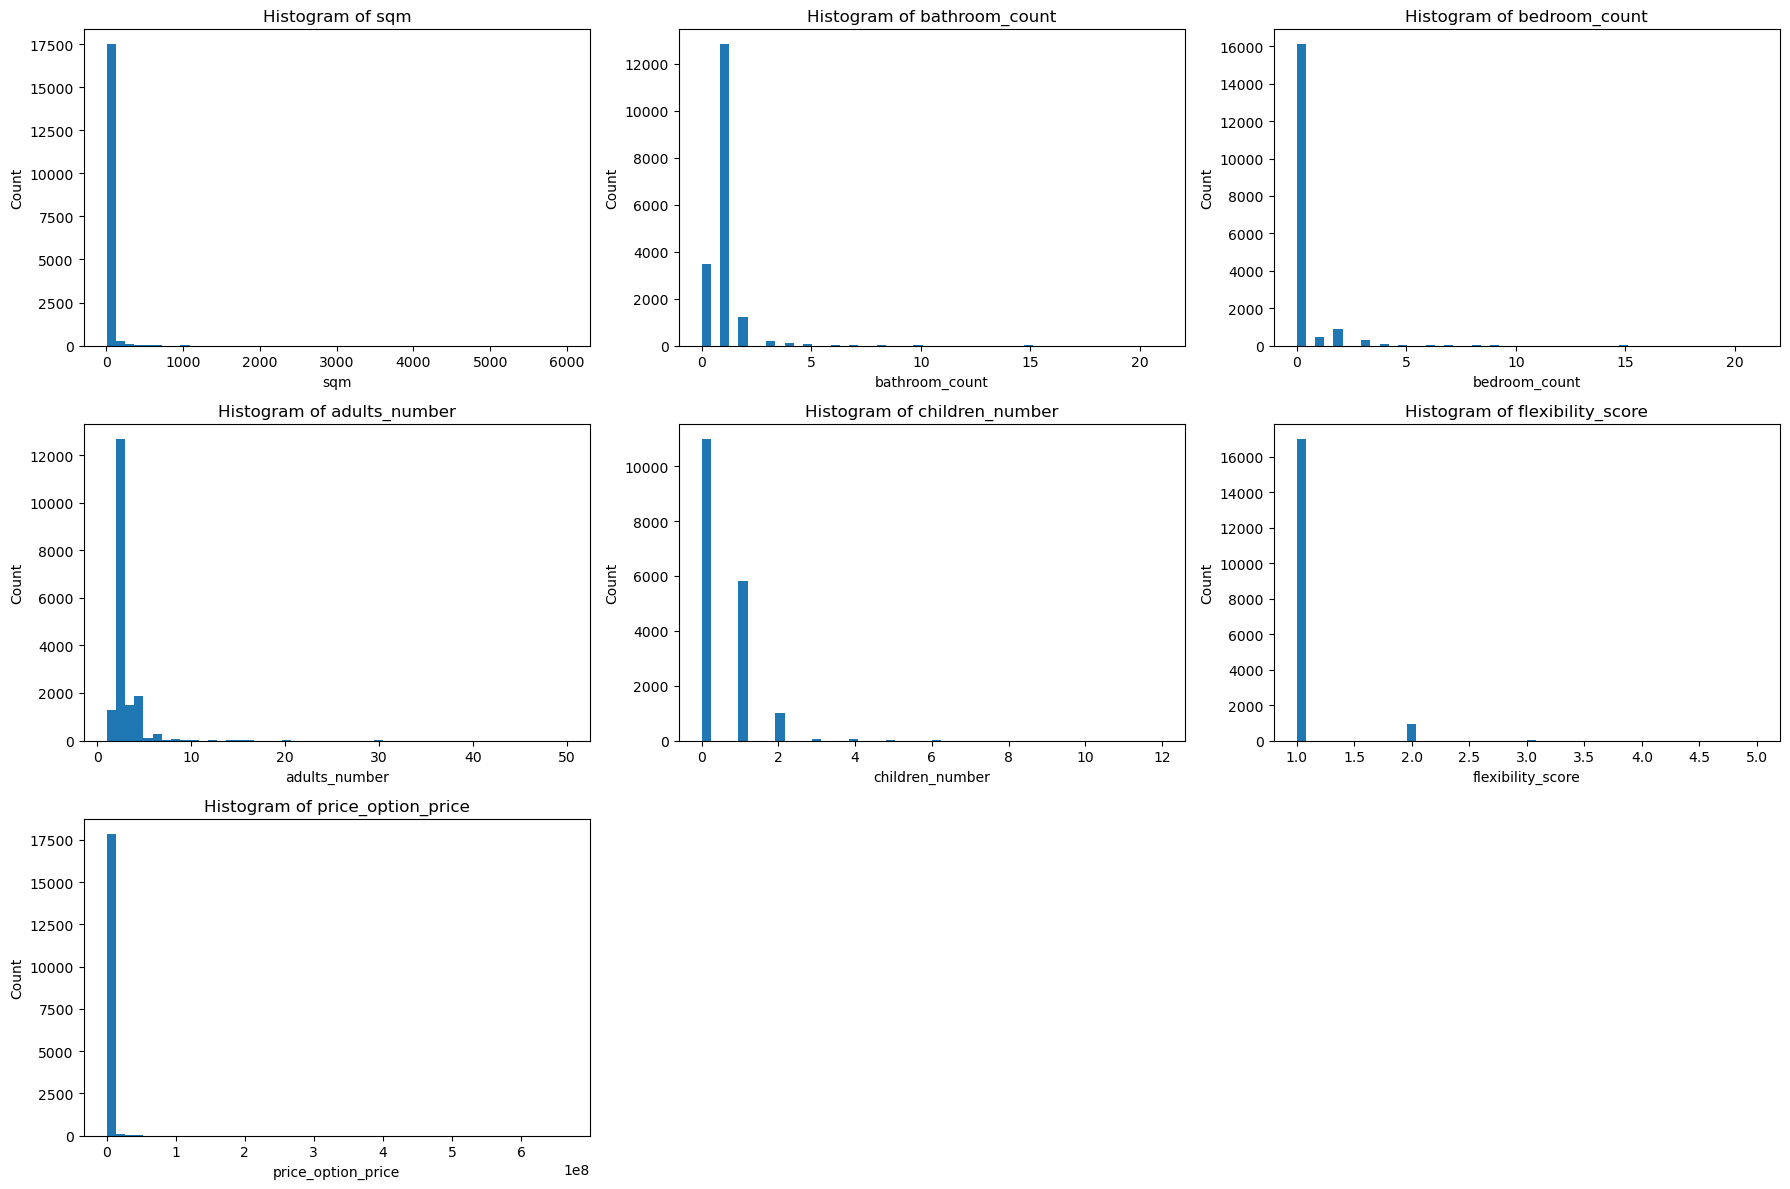

In [30]:
import math
import matplotlib.pyplot as plt

n_cols = 3
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

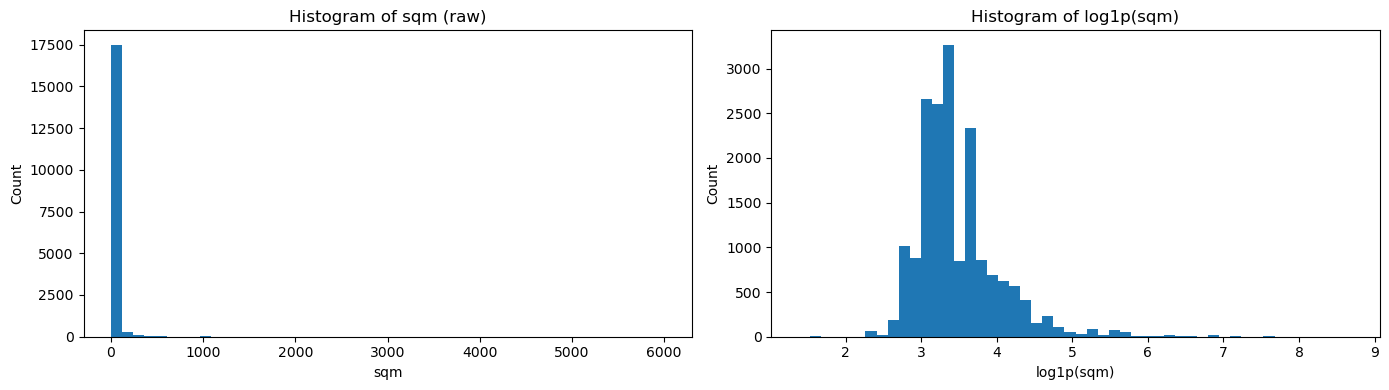

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,4))

# Raw sqm
plt.subplot(1,2,1)
plt.hist(df['sqm'], bins=50)
plt.title("Histogram of sqm (raw)")
plt.xlabel("sqm")
plt.ylabel("Count")

# log1p(sqm)
plt.subplot(1,2,2)
plt.hist(np.log1p(df['sqm']), bins=50)
plt.title("Histogram of log1p(sqm)")
plt.xlabel("log1p(sqm)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

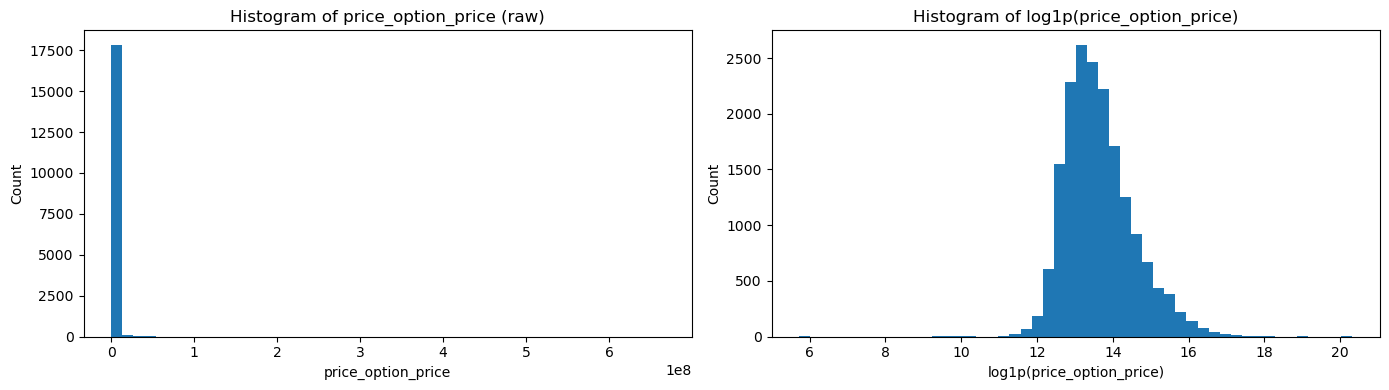

In [32]:
plt.figure(figsize=(14,4))

# Raw price
plt.subplot(1,2,1)
plt.hist(df['price_option_price'], bins=50)
plt.title("Histogram of price_option_price (raw)")
plt.xlabel("price_option_price")
plt.ylabel("Count")

# log1p(price)
plt.subplot(1,2,2)
plt.hist(np.log1p(df['price_option_price']), bins=50)
plt.title("Histogram of log1p(price_option_price)")
plt.xlabel("log1p(price_option_price)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

`sqm` (room size)
- The raw distribution of `sqm` is **highly right-skewed** with a very long tail.
- Most observations are concentrated in the range of **~20–50 m²**, which aligns with typical hotel room sizes.
- However, there are **extreme outliers** (up to **6000 m²**), which strongly distort the raw histogram.
- After applying `log1p(sqm)`, the distribution becomes much more interpretable and shows a smoother unimodal shape, indicating that the majority of room sizes are clustered around a typical range with a few large-size listings.

`price_option_price` (room price)
- The raw price distribution is also **extremely right-skewed** due to rare but very large values (heavy long-tail).
- The presence of extreme outliers makes the raw histogram almost unreadable, as most values collapse near the lower end.
- After applying `log1p(price_option_price)`, the distribution becomes approximately bell-shaped, suggesting that prices follow a log-normal–like distribution.
- This indicates that **log transformation is necessary** for robust statistical analysis and modeling, and outlier handling may also be considered.

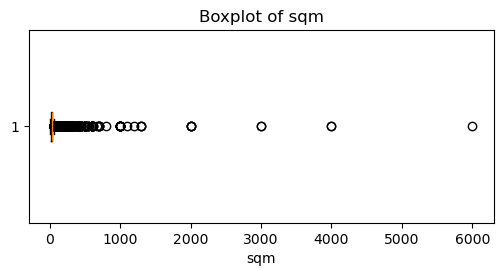

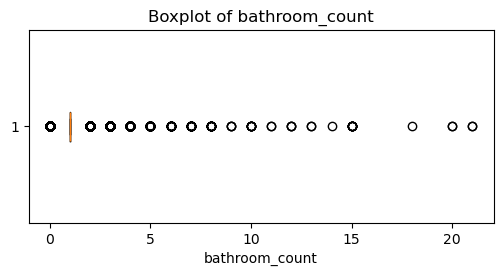

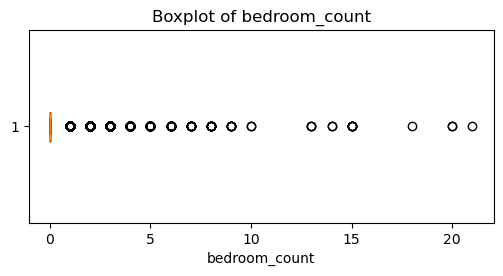

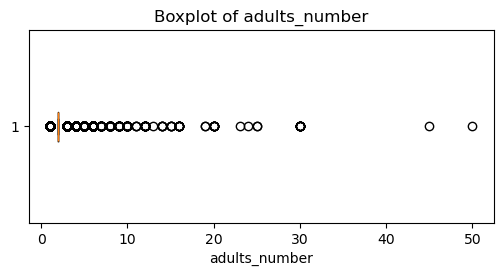

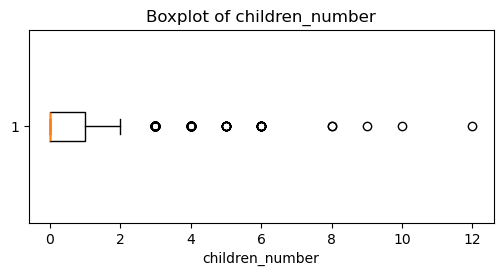

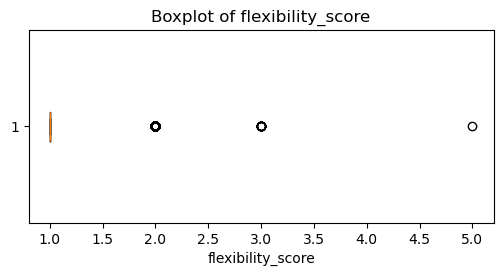

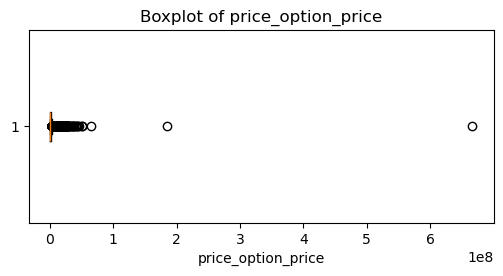

In [33]:
for col in num_col:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

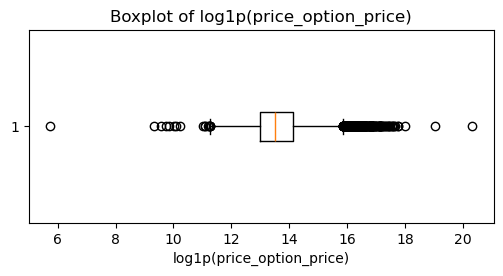

In [34]:
plt.figure(figsize=(6,2.5))
plt.boxplot(np.log1p(df['price_option_price']), vert=False)
plt.title("Boxplot of log1p(price_option_price)")
plt.xlabel("log1p(price_option_price)")
plt.show()

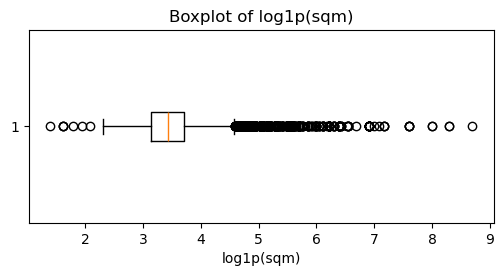

In [35]:
plt.figure(figsize=(6,2.5))
plt.boxplot(np.log1p(df['sqm']), vert=False)
plt.title("Boxplot of log1p(sqm)")
plt.xlabel("log1p(sqm)")
plt.show()

`price_option_price`
- In the **raw boxplot**, the IQR is highly compressed near the lower values due to extreme high-price outliers.
- After applying **`log1p(price_option_price)`**, the distribution becomes much more interpretable:
  - The central spread (IQR) is now clearly visible.
  - Outliers still exist, but their influence is significantly reduced.
- This confirms that the room price follows a **heavy long-tail distribution**, and **log transformation is necessary** for robust analysis and modeling.

`sqm`
- The **raw sqm boxplot** shows most room sizes concentrated in a small range, while extreme outliers extend far to the right (up to 6000 m²).
- After applying **`log1p(sqm)`**, the distribution becomes more compact and readable:
  - Most observations cluster tightly around a typical hotel-room size range.
  - Large-size listings still appear as outliers but are less dominant.
- This suggests that `sqm` also has a long-tail pattern, and log transformation improves interpretability.

**Overall conclusion:**  
Both `price_option_price` and `sqm` contain extreme outliers and right-skewness.  
Using **`log1p()` transformation** helps stabilize variance, reduces the effect of outliers, and reveals the underlying structure of the data more clearly.

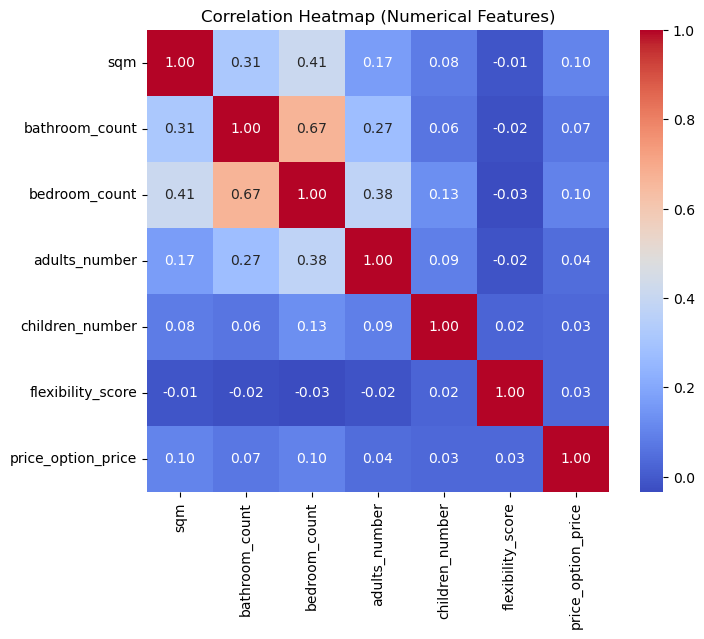

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[num_col].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

The correlation heatmap shows several meaningful relationships between room-size/capacity-related variables, while correlations with the target variable (`price_option_price`) remain relatively weak.

**Strong / Moderate correlations**
- **`bathroom_count` and `bedroom_count` (corr ≈ 0.67)** have the strongest positive relationship, which is expected: larger accommodations (villas/apartments) usually contain more bathrooms and bedrooms.
- **`sqm` and `bedroom_count` (corr ≈ 0.41)** also show a moderate positive correlation, indicating that rooms with more bedrooms tend to be larger in size.
- **`sqm` and `bathroom_count` (corr ≈ 0.31)** further support that larger rooms often come with more bathrooms.
- **`adults_number` correlates moderately with `bedroom_count` (corr ≈ 0.38)** and `bathroom_count` (corr ≈ 0.27), suggesting room capacity increases with accommodation size.

**Weak correlations with `price_option_price`**
- Correlations between numerical features and the target `price_option_price` are all **weak** (mostly below **0.10**).
- The highest correlations with price are:
  - `sqm` (≈ 0.10)
  - `bedroom_count` (≈ 0.10)
- This suggests that **price is not strongly explained by simple linear relationships** with these numeric variables alone.
- The weak correlations can be due to:
  - heavy skewness/outliers in price
  - non-linear relationships
  - strong influence of categorical factors (e.g., region, hotel name, room type)

**Notes on `flexibility_score`**
- `flexibility_score` has nearly **zero correlation** with other numerical variables, meaning it provides largely independent information.
- However, low linear correlation does not imply it is useless; it may still help in non-linear models.

**Conclusion:**  
The numerical features mainly capture **room size/capacity structure**, while room price appears to depend strongly on **categorical/contextual factors** and potentially **non-linear interactions**. Therefore, using log-transformed price and non-linear models (e.g., tree-based methods) may be more appropriate for prediction tasks.


### Categorical feature

In [37]:
cat_col

['views', 'room_room_type_name', 'region']

In [38]:
df[cat_col].nunique().sort_values(ascending=False)

room_room_type_name    3143
region                   42
views                     7
dtype: int64

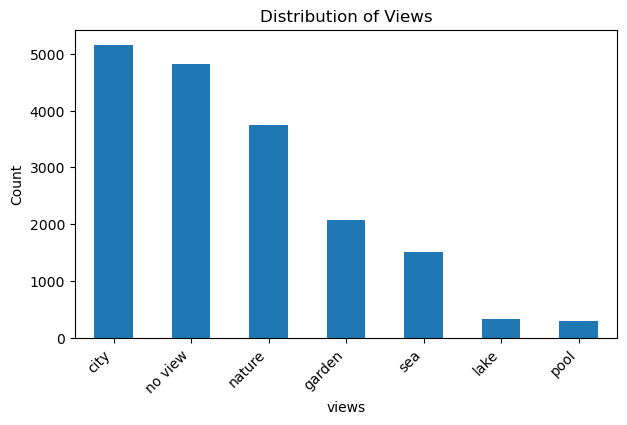

In [39]:
views_count = df['views'].value_counts()

plt.figure(figsize=(7,4))
views_count.plot(kind='bar')
plt.title("Distribution of Views")
plt.xlabel("views")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

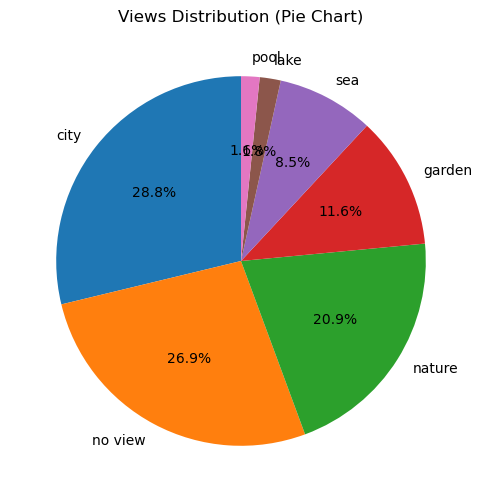

In [40]:
plt.figure(figsize=(6,6))
plt.pie(views_count, labels=views_count.index, autopct='%1.1f%%', startangle=90)
plt.title("Views Distribution (Pie Chart)")
plt.show()

The feature `views` contains **7 categories**, with a highly imbalanced distribution.

**Key observations**
- **City view** is the most common category (**~28.8%**).
- **No view** is the second most frequent (**~26.9%**).
- **Nature view** also accounts for a large portion (**~20.9%**).
- **Garden view** and **Sea view** are less common (**~11.6%** and **~8.5%**, respectively).
- **Lake view** and **Pool view** are rare categories (together only a small fraction of the data).

**Conclusion:**  
Most rooms fall into a few dominant view types (`city`, `no view`, `nature`). Rare categories such as `lake` and `pool` may have limited statistical power in downstream analysis/modeling and could be grouped into an “Others” category if needed.

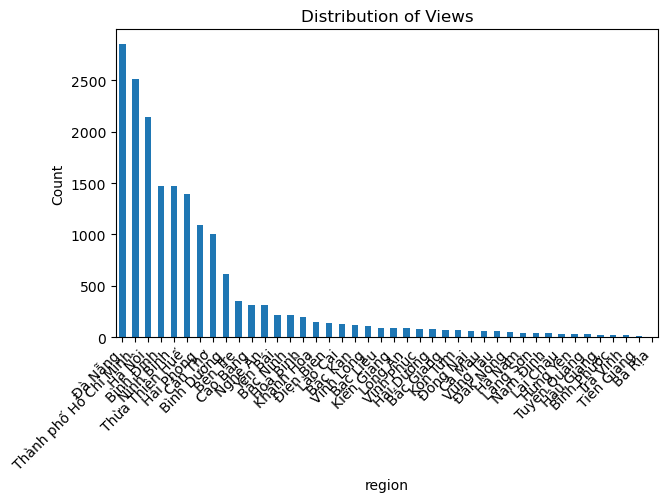

In [41]:
views_count = df['region'].value_counts()

plt.figure(figsize=(7,4))
views_count.plot(kind='bar')
plt.title("Distribution of Views")
plt.xlabel("region")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

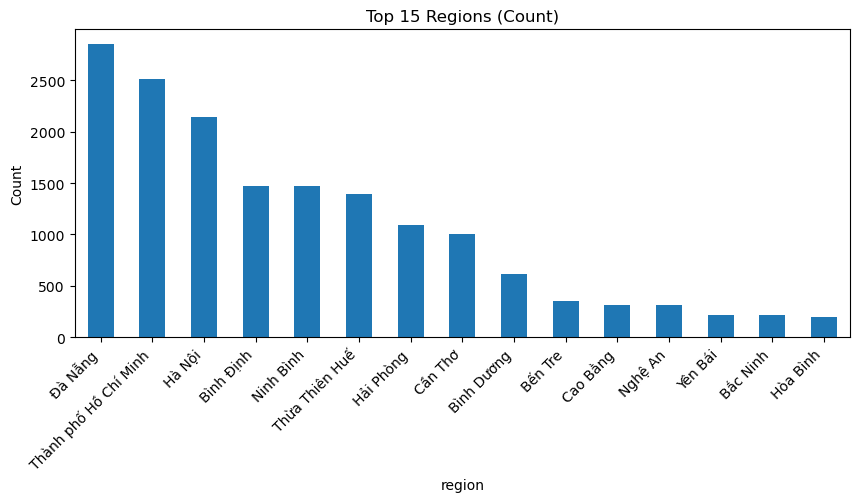

In [42]:
region_count = df['region'].value_counts().head(15)

plt.figure(figsize=(10,4))
region_count.plot(kind='bar')
plt.title("Top 15 Regions (Count)")
plt.xlabel("region")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

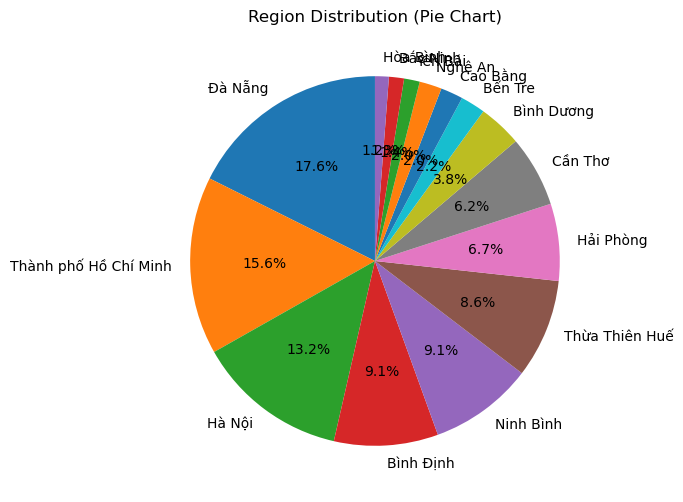

In [43]:
plt.figure(figsize=(6,6))
plt.pie(region_count, labels=region_count.index, autopct='%1.1f%%', startangle=90)
plt.title("Region Distribution (Pie Chart)")
plt.show()

The dataset contains **42 unique regions**, but the distribution is clearly **imbalanced**.  
A small number of regions contribute the majority of observations, while many regions appear only with a small number of samples.

**Top regions by frequency**
From the Top 15 bar chart and pie chart:
- **Đà Nẵng** has the largest share (**~17.6%**).
- **TP. Hồ Chí Minh** follows (**~15.6%**).
- **Hà Nội** is also highly represented (**~13.2%**).
- The next notable regions include **Bình Định (~9.1%)**, **Ninh Bình (~9.1%)**, **Thừa Thiên Huế (~8.6%)**, and **Hải Phòng (~6.7%)**.
- The remaining regions each contribute a relatively small portion of the dataset (mostly below ~5%).

                                                                                   **Conclusion:**  
The dataset is heavily concentrated in a few major tourist/business cities.  
For visualization clarity, it is reasonable to focus on the **Top 15 regions**, as the remaining regions have much lower frequencies and would make plots difficult to interpret.

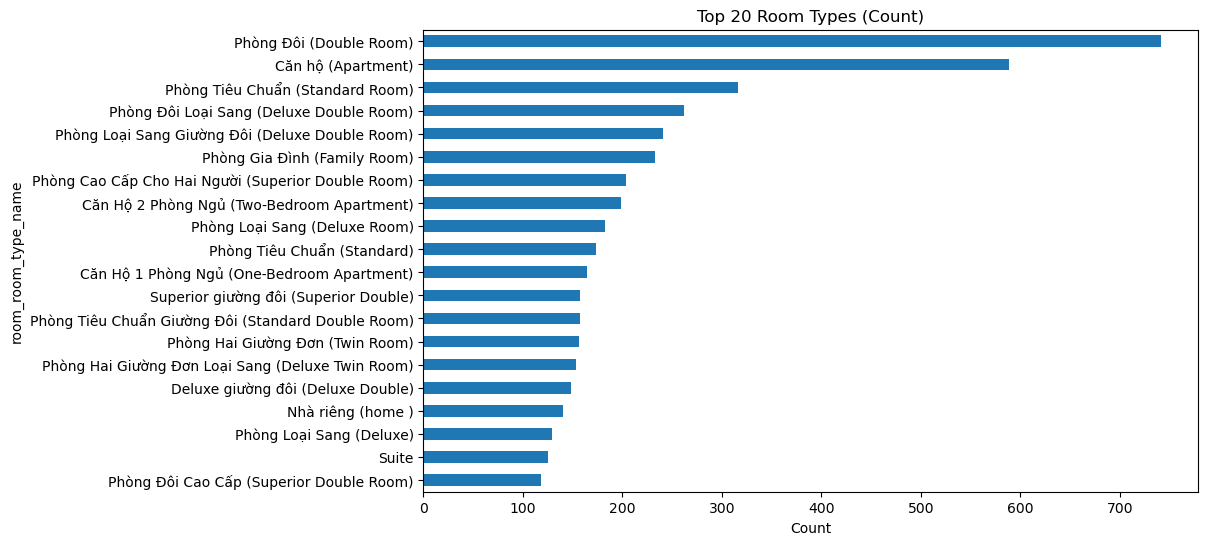

In [44]:
room_count = df["room_room_type_name"].value_counts().head(20)

plt.figure(figsize=(10,6))
room_count.sort_values().plot(kind="barh")
plt.title("Top 20 Room Types (Count)")
plt.xlabel("Count")
plt.ylabel("room_room_type_name")
plt.show()

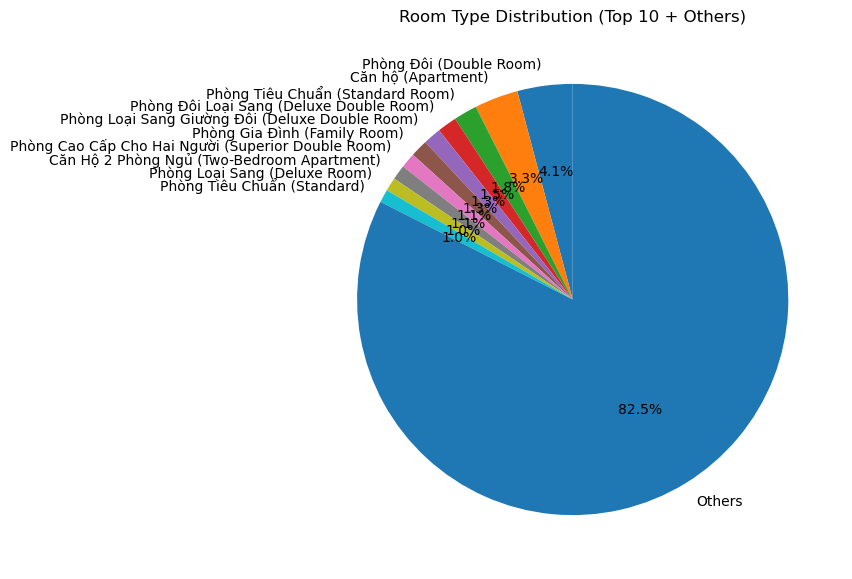

In [45]:
room_count_all = df["room_room_type_name"].value_counts()
top10 = room_count_all.head(10)
others = room_count_all.iloc[10:].sum()

pie_data = pd.concat([top10, pd.Series({"Others": others})])

plt.figure(figsize=(7,7))
plt.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=90)
plt.title("Room Type Distribution (Top 10 + Others)")
plt.show()

The feature `room_room_type_name` has **very high cardinality** (**3143 unique values**), indicating a strong long-tail distribution.

**Key observations (Top 20)**
- The most frequent room type is **“Phòng Đôi (Double Room)”**, which appears significantly more than all other room types.
- Other common room types include:
  - **“Căn hộ (Apartment)”**
  - **“Phòng Tiêu Chuẩn (Standard Room)”**
  - **“Phòng Đôi Loại Sang / Deluxe Double Room”**
  - **“Family Room”**, **Superior Double**, **Twin Room**, and **Suite**
- The distribution drops quickly after the top few categories, meaning that most room types appear only a small number of times.

**Pie chart insight (Top 10 + Others)**
- The **Top 10 room types account for only a small portion** of the dataset.
- The category **“Others” dominates (~82.5%)**, showing that most room type names occur rarely.
- This confirms that the variable follows a **heavy long-tail / sparse categorical distribution**.

**Conclusion:**  
Due to the extremely high number of unique room type names, it is not practical to analyze or encode all categories directly.  
EDA and feature engineering should focus on:
- the **most frequent room types**, and/or  
- extracting meaningful **keywords** (e.g., *Standard, Deluxe, Suite, Apartment, Villa, Family*) from room names.


### Binary feature

In [46]:
bin_col

['large_double_bed',
 'large_bed',
 'single_bed',
 'sofa_bed',
 'double_bed',
 'small_double_bed',
 'king_size_bed',
 'futon_mattress',
 'bunk_bed',
 'is_private_bathroom',
 'balcony-terrace',
 'closet',
 'air_conditioning',
 'hair_dryer',
 'complimentary-bottled-water',
 'bathtub',
 'shower',
 'refrigerator',
 'high-floor',
 'dressing-room',
 'ground-floor',
 'private-pool',
 'top-floor',
 'complimentary-instant-coffee',
 'electric-blanket',
 'free-welcome-drink',
 'low-floor',
 'complimentary-tea',
 'coffee-tea-maker',
 'hot-spring-access',
 'bãi_đậu_xe',
 'phòng_tập',
 'wifi_miễn_phí',
 'không_hoàn_tiền',
 'miễn_phí_hủy',
 'vào_hồ_bơi_miễn_phí',
 'đã_kèm_bữa_sáng',
 'hotel_name']

In [47]:
bin_cols = [c for c in bin_col if c != 'hotel_name']

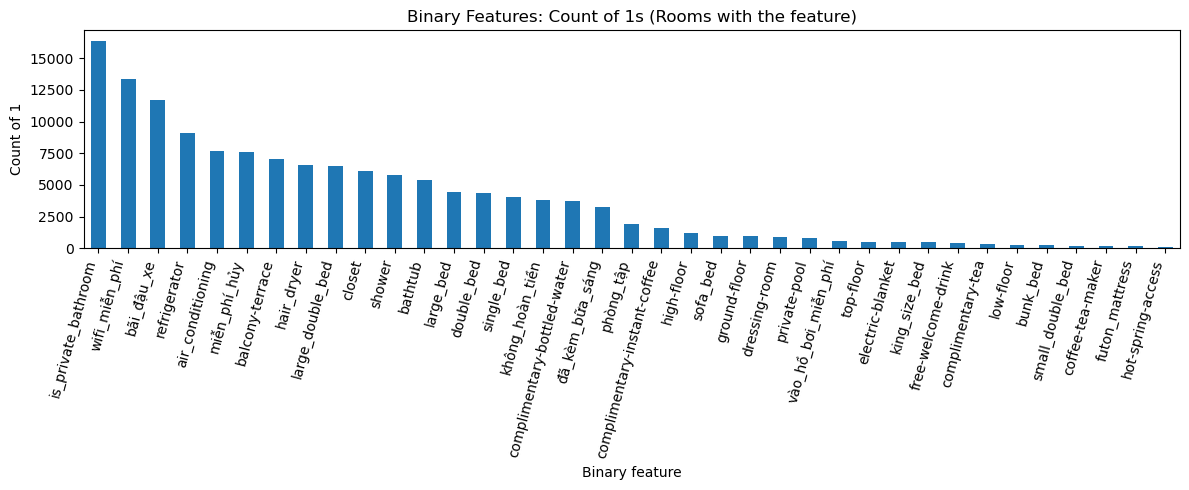

In [48]:
ones_count = df[bin_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
ones_count.plot(kind='bar')
plt.title("Binary Features: Count of 1s (Rooms with the feature)")
plt.xlabel("Binary feature")
plt.ylabel("Count of 1")
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

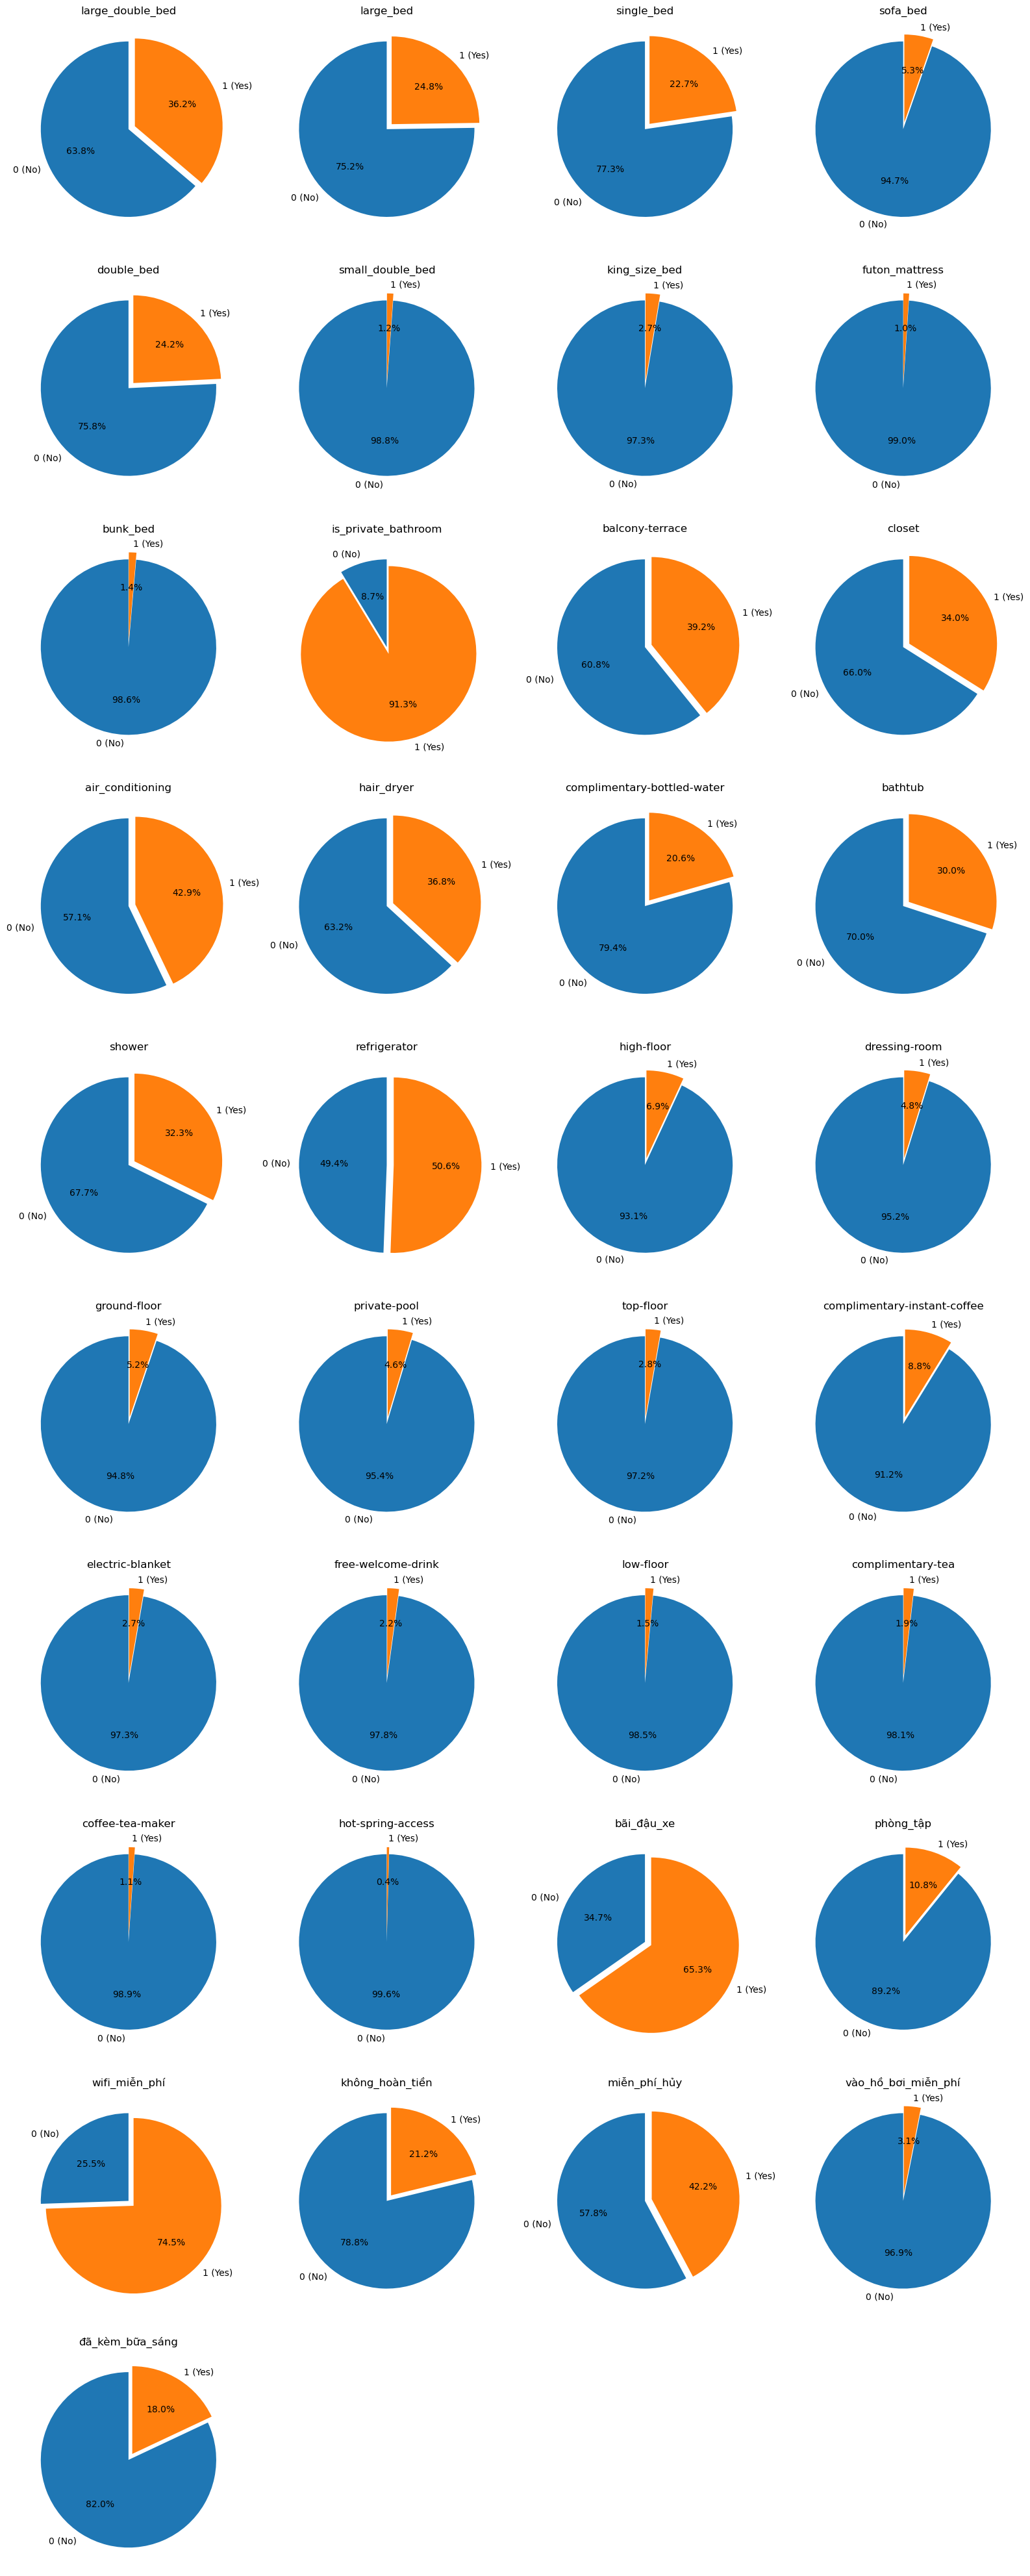

In [49]:
features = bin_cols
n_cols = 4

n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    counts = df[col].value_counts().reindex([0,1], fill_value=0)
    
    axes[i].pie(
        counts,
        labels=['0 (No)', '1 (Yes)'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0, 0.08]
    )
    axes[i].set_title(col)

# Xóa subplot dư
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Binary features represent room amenities and bed types (0 = not available, 1 = available).  
The bar chart of counts and the pie charts reveal that most binary variables are **highly imbalanced**, meaning only a small portion of rooms contain certain amenities.

**Most common binary features**
Several amenities appear in a large proportion of rooms:
- **WiFi miễn phí** is very common (**~74.5%** of rooms have it).
- **Bãi đậu xe** is also frequent (**~65.3%**).
- **Miễn phí hủy** appears in a significant share (**~42.2%**).
- Bathroom-related features such as **is_private_bathroom** are highly prevalent (**~91%**).
- Common room facilities like **air_conditioning (~42.9%)**, **balcony/terrace (~39.2%)**, and **closet (~34.0%)** occur regularly.

**Rare / luxury amenities**
Many features are rare and appear in only a small number of rooms:
- **private_pool (~4–5%)**, **hot_spring_access (~0.4%)**, and specialty bed types (e.g., **bunk_bed, futon_mattress**) are extremely uncommon.
- Floor-related features such as **top-floor**, **low-floor**, **ground-floor**, and **high-floor** are also relatively rare.
- Complimentary items such as **free-welcome-drink**, **coffee-tea-maker**, and **electric-blanket** occur in only a small fraction of rooms.

**Bed-type availability**
The distribution of bed-type columns indicates that most rooms contain a limited number of bed configurations:
- Some bed types are moderately common (e.g., large_double_bed, large_bed, double_bed, single_bed),
- while others such as king_size_bed, futon_mattress, and bunk_bed are rare.

**Conclusion:**  
Binary features show strong imbalance: a few amenities dominate the dataset, while many others are very sparse.  
This is expected for hotel amenities data, and it suggests that rare features may have limited statistical influence in EDA and may require careful handling in modeling (e.g., grouping, regularization, or feature selection).


**Note:** Highly sparse binary features may not provide reliable patterns on their own due to low support, but they can still be useful in combination with other features (e.g., region, room type, and size).


## EDA: Multipple feature

This dataset contains a relatively large number of features (numerical, categorical, and many binary amenity indicators).  
Instead of performing detailed EDA for every single variable, we adopt a **target-driven approach** and focus on features that are most likely to influence the room price (`price_option_price`).

In particular, we prioritize:
- **High-impact categorical factors** such as `region`, `views`, and high-level room-type information (e.g., extracted from `room_room_type_name`),
- **Core numerical drivers** such as room size (`sqm`) and capacity-related counts (`adults_number`, `bathroom_count`, `bedroom_count`),
- A **small subset of representative binary amenities**, including both common amenities (e.g., WiFi, parking) and luxury-related amenities (e.g., private pool).

This selective strategy improves interpretability, avoids overly repetitive visualizations, and highlights the most meaningful patterns between the target and key explanatory variables.


In [50]:
target = "price_option_price"
df["log_price"] = np.log1p(df[target])

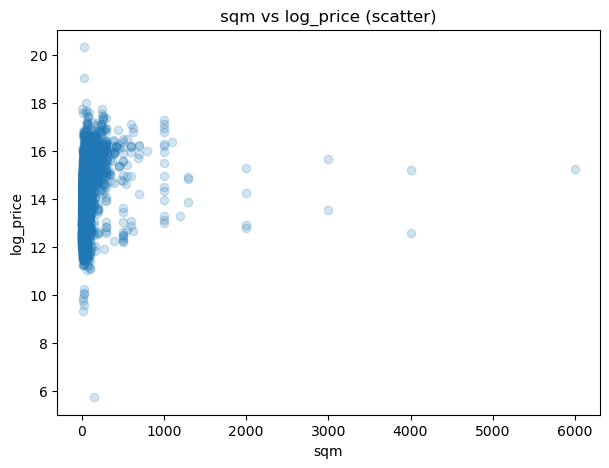

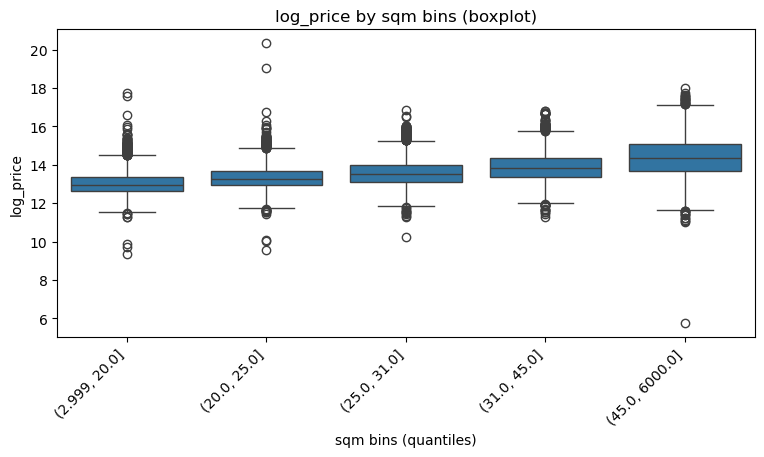

In [51]:
feat = "sqm"

# Scatter
plt.figure(figsize=(7,5))
plt.scatter(df[feat], df["log_price"], alpha=0.2)
plt.title(f"{feat} vs log_price (scatter)")
plt.xlabel(feat)
plt.ylabel("log_price")
plt.show()

# Boxplot (group by bins để boxplot có ý nghĩa)
df[f"{feat}_bin"] = pd.qcut(df[feat], q=5, duplicates="drop")  # chia 5 nhóm theo quantile

plt.figure(figsize=(9,4))
sns.boxplot(data=df, x=f"{feat}_bin", y="log_price")
plt.title(f"log_price by {feat} bins (boxplot)")
plt.xlabel(f"{feat} bins (quantiles)")
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()

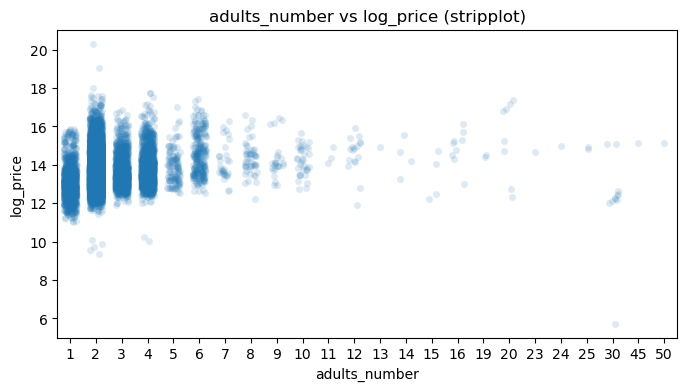

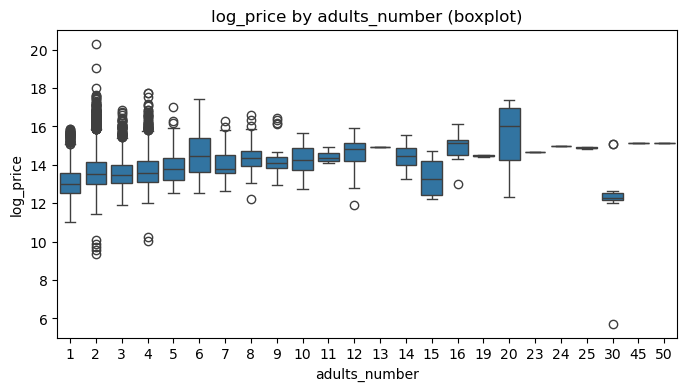

In [52]:
feat = "adults_number"   # đổi sang bathroom_count, bedroom_count...

# "Scatter-like" (stripplot)  
plt.figure(figsize=(8,4))
sns.stripplot(data=df, x=feat, y="log_price", jitter=0.25, alpha=0.15)
plt.title(f"{feat} vs log_price (stripplot)")
plt.xlabel(feat)
plt.ylabel("log_price")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x=feat, y="log_price")
plt.title(f"log_price by {feat} (boxplot)")
plt.xlabel(feat)
plt.ylabel("log_price")
plt.show()

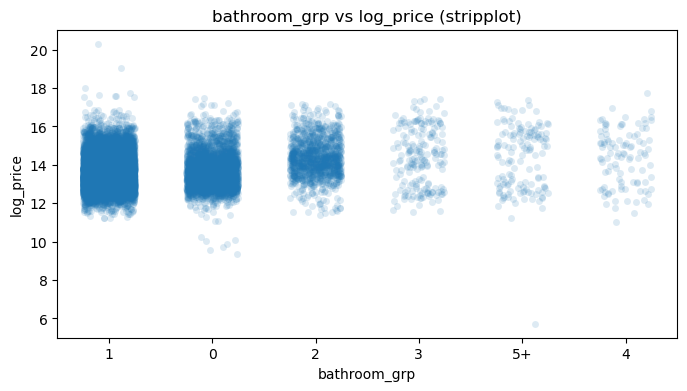

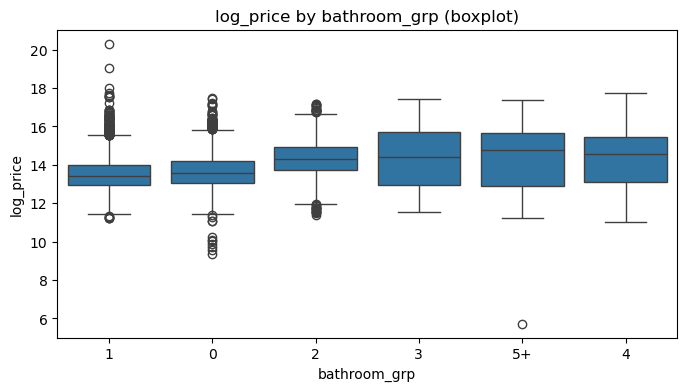

In [53]:
feat = "bathroom_count"
grp = "bathroom_grp"

df[grp] = df[feat].clip(upper=5).astype(str)
df.loc[df[feat] >= 5, grp] = "5+"

# Stripplot
plt.figure(figsize=(8,4))
sns.stripplot(data=df, x=grp, y="log_price", jitter=0.25, alpha=0.15)
plt.title(f"{grp} vs log_price (stripplot)")
plt.xlabel(grp)
plt.ylabel("log_price")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x=grp, y="log_price")
plt.title(f"log_price by {grp} (boxplot)")
plt.xlabel(grp)
plt.ylabel("log_price")
plt.show()

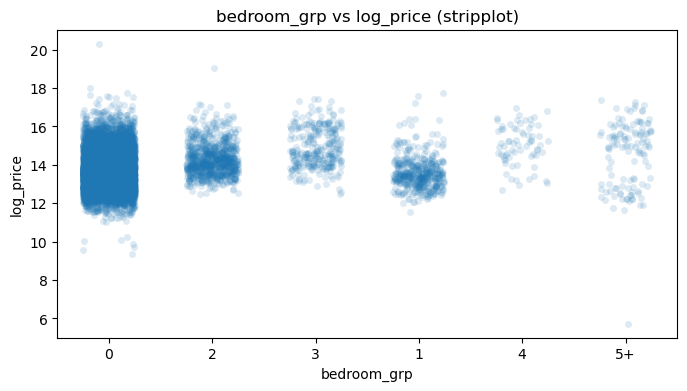

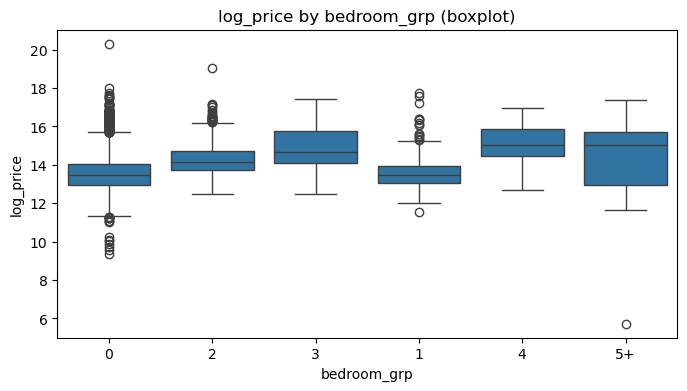

In [54]:
feat = "bedroom_count"
grp = "bedroom_grp"

df[grp] = df[feat].clip(upper=5).astype(str)
df.loc[df[feat] >= 5, grp] = "5+"

# Stripplot
plt.figure(figsize=(8,4))
sns.stripplot(data=df, x=grp, y="log_price", jitter=0.25, alpha=0.15)
plt.title(f"{grp} vs log_price (stripplot)")
plt.xlabel(grp)
plt.ylabel("log_price")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x=grp, y="log_price")
plt.title(f"log_price by {grp} (boxplot)")
plt.xlabel(grp)
plt.ylabel("log_price")
plt.show()

**log_price vs Numerical Features (Summary)**

Overall, numerical features related to **room size and capacity** show a clear relationship with `log_price`.  
- **`sqm`** has a positive trend: larger rooms tend to be more expensive.  
- **`adults_number`**, **`bathroom_count`**, and **`bedroom_count`** generally show increasing `log_price` as values increase, indicating higher-capacity/larger accommodations are priced higher.  
- Higher counts (e.g., 3+ bedrooms or 5+ bathrooms) show wider variation due to small sample size and heterogeneous listing types.


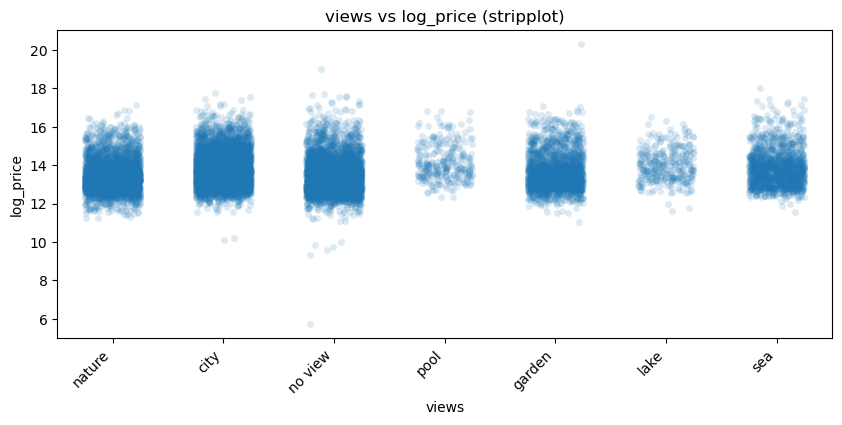

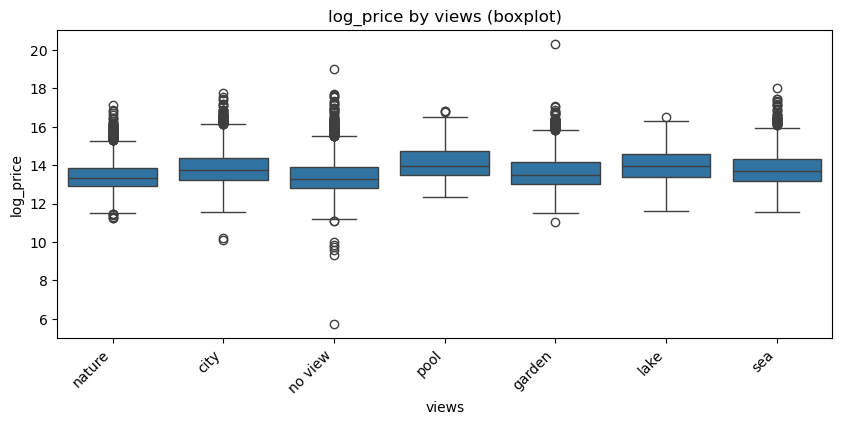

In [55]:
feat = "views"

# Stripplot (scatter-like)
plt.figure(figsize=(10,4))
sns.stripplot(data=df, x=feat, y="log_price", jitter=0.25, alpha=0.15)
plt.title(f"{feat} vs log_price (stripplot)")
plt.xlabel(feat)
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()

# Boxplot
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x=feat, y="log_price")
plt.title(f"log_price by {feat} (boxplot)")
plt.xlabel(feat)
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()


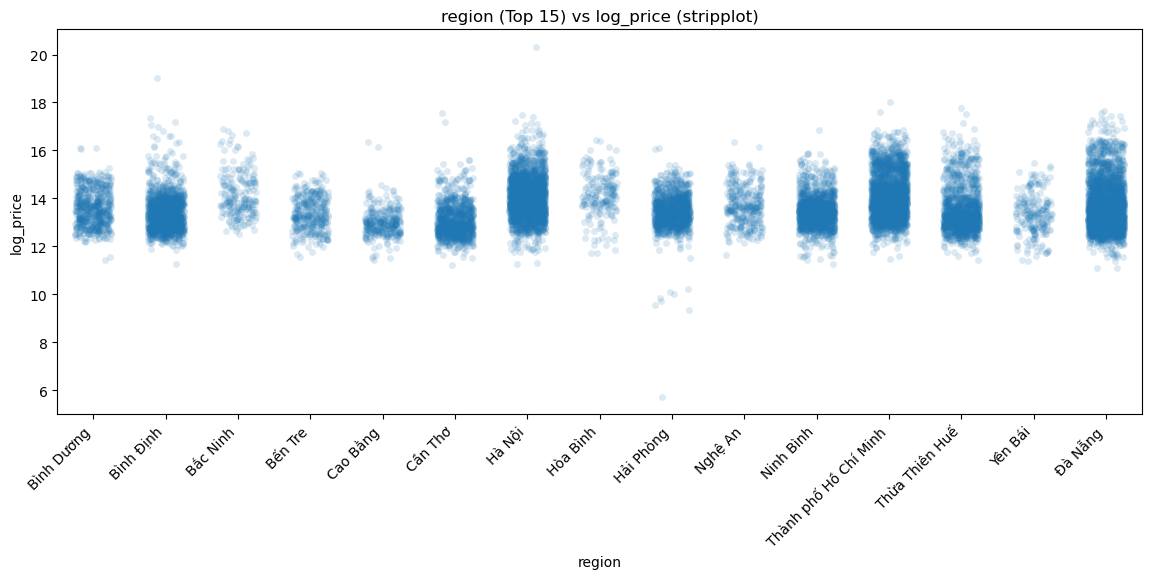

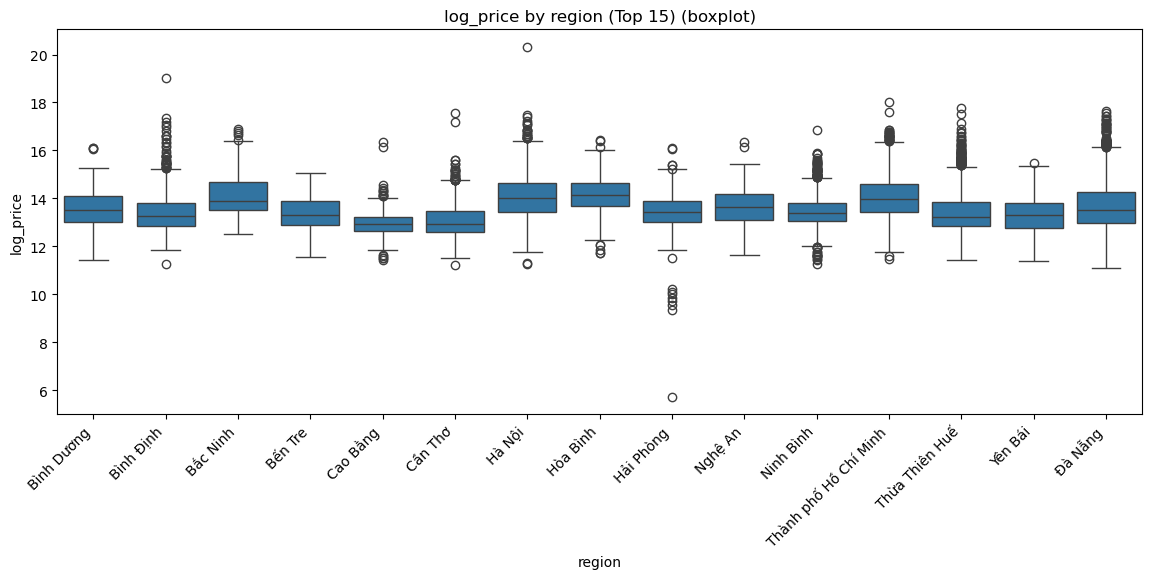

In [56]:
feat = "region"
top_regions = df[feat].value_counts().head(15).index
tmp = df[df[feat].isin(top_regions)]

# Stripplot
plt.figure(figsize=(14,5))
sns.stripplot(data=tmp, x=feat, y="log_price", jitter=0.25, alpha=0.15)
plt.title("region (Top 15) vs log_price (stripplot)")
plt.xticks(rotation=45, ha="right")
plt.show()

# Boxplot
plt.figure(figsize=(14,5))
sns.boxplot(data=tmp, x=feat, y="log_price")
plt.title("log_price by region (Top 15) (boxplot)")
plt.xticks(rotation=45, ha="right")
plt.show()

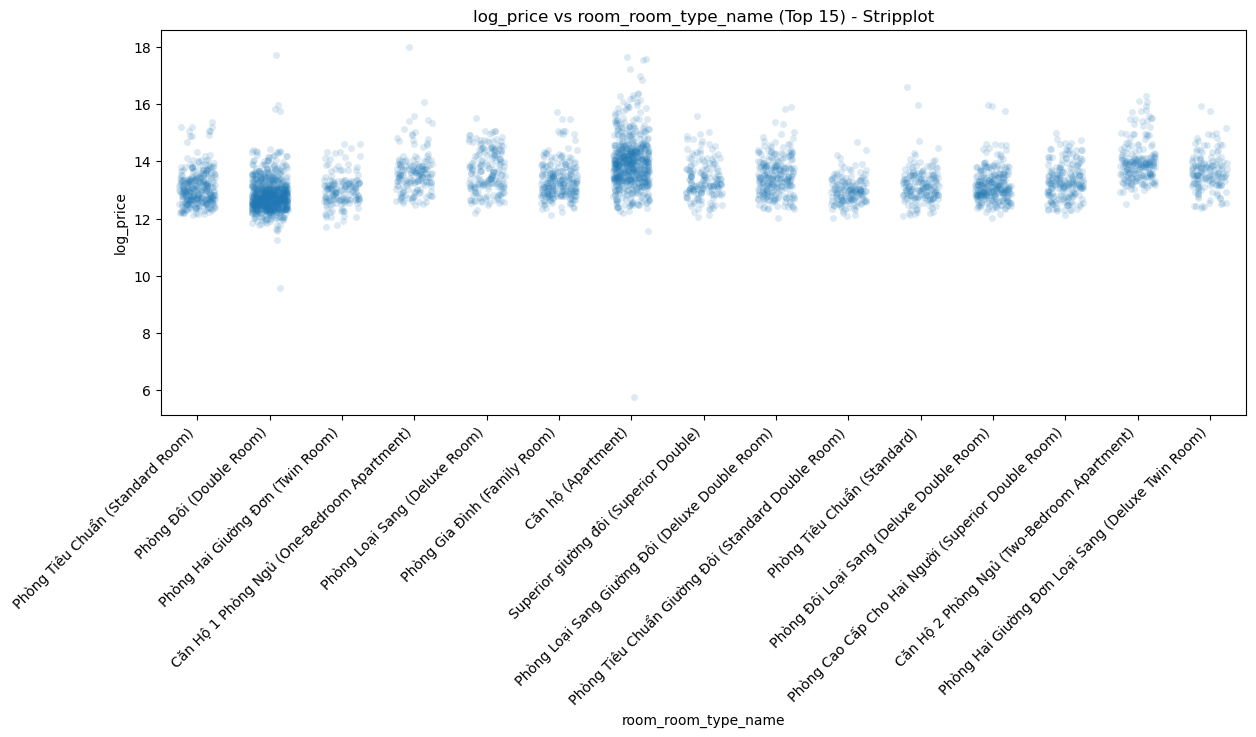

In [57]:
top_rooms = df["room_room_type_name"].value_counts().head(15).index
df_top_room = df[df["room_room_type_name"].isin(top_rooms)]

plt.figure(figsize=(14,5))
sns.stripplot(data=df_top_room, x="room_room_type_name", y="log_price",
              jitter=0.25, alpha=0.15)
plt.title("log_price vs room_room_type_name (Top 15) - Stripplot")
plt.xlabel("room_room_type_name")
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()

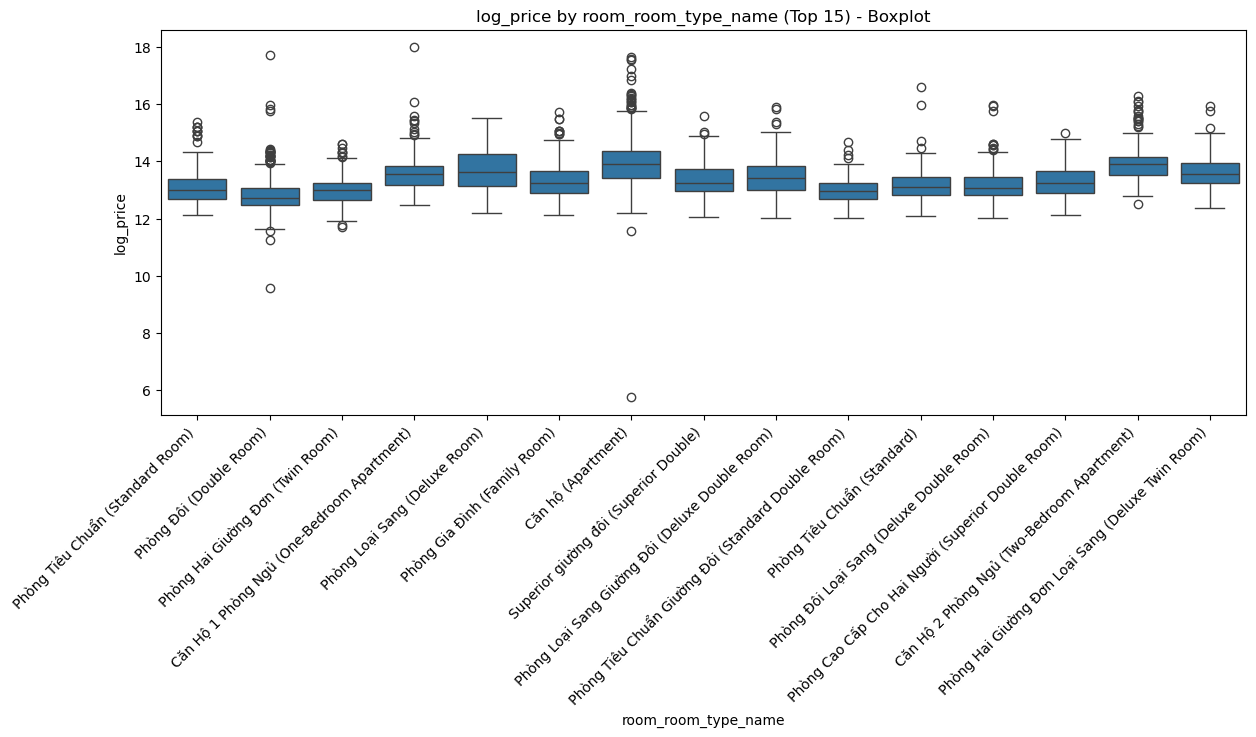

In [58]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df_top_room, x="room_room_type_name", y="log_price")
plt.title("log_price by room_room_type_name (Top 15) - Boxplot")
plt.xlabel("room_room_type_name")
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()

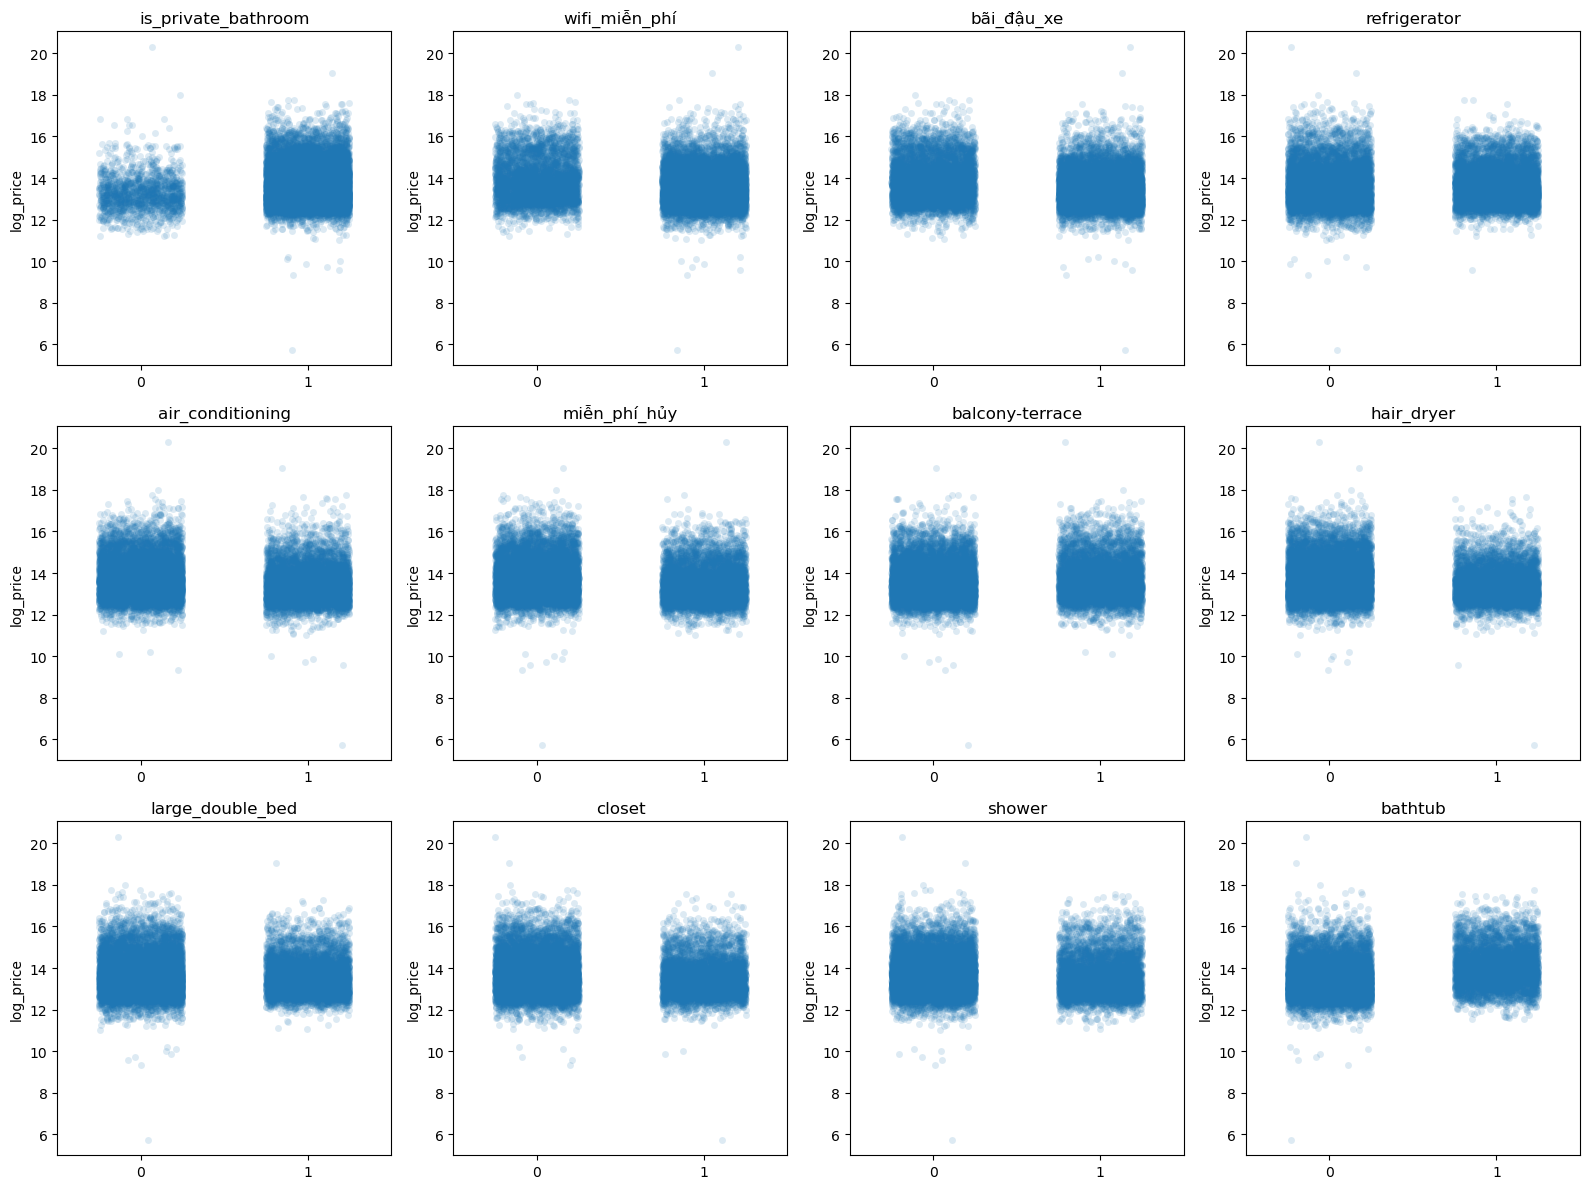

In [59]:
import math

bin_cols = [c for c in bin_col if c != "hotel_name"]
top_bin = df[bin_cols].sum().sort_values(ascending=False).head(12).index

n_cols = 4
n_rows = math.ceil(len(top_bin) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(top_bin):
    sns.stripplot(data=df, x=col, y="log_price", jitter=0.25, alpha=0.15, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("log_price")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

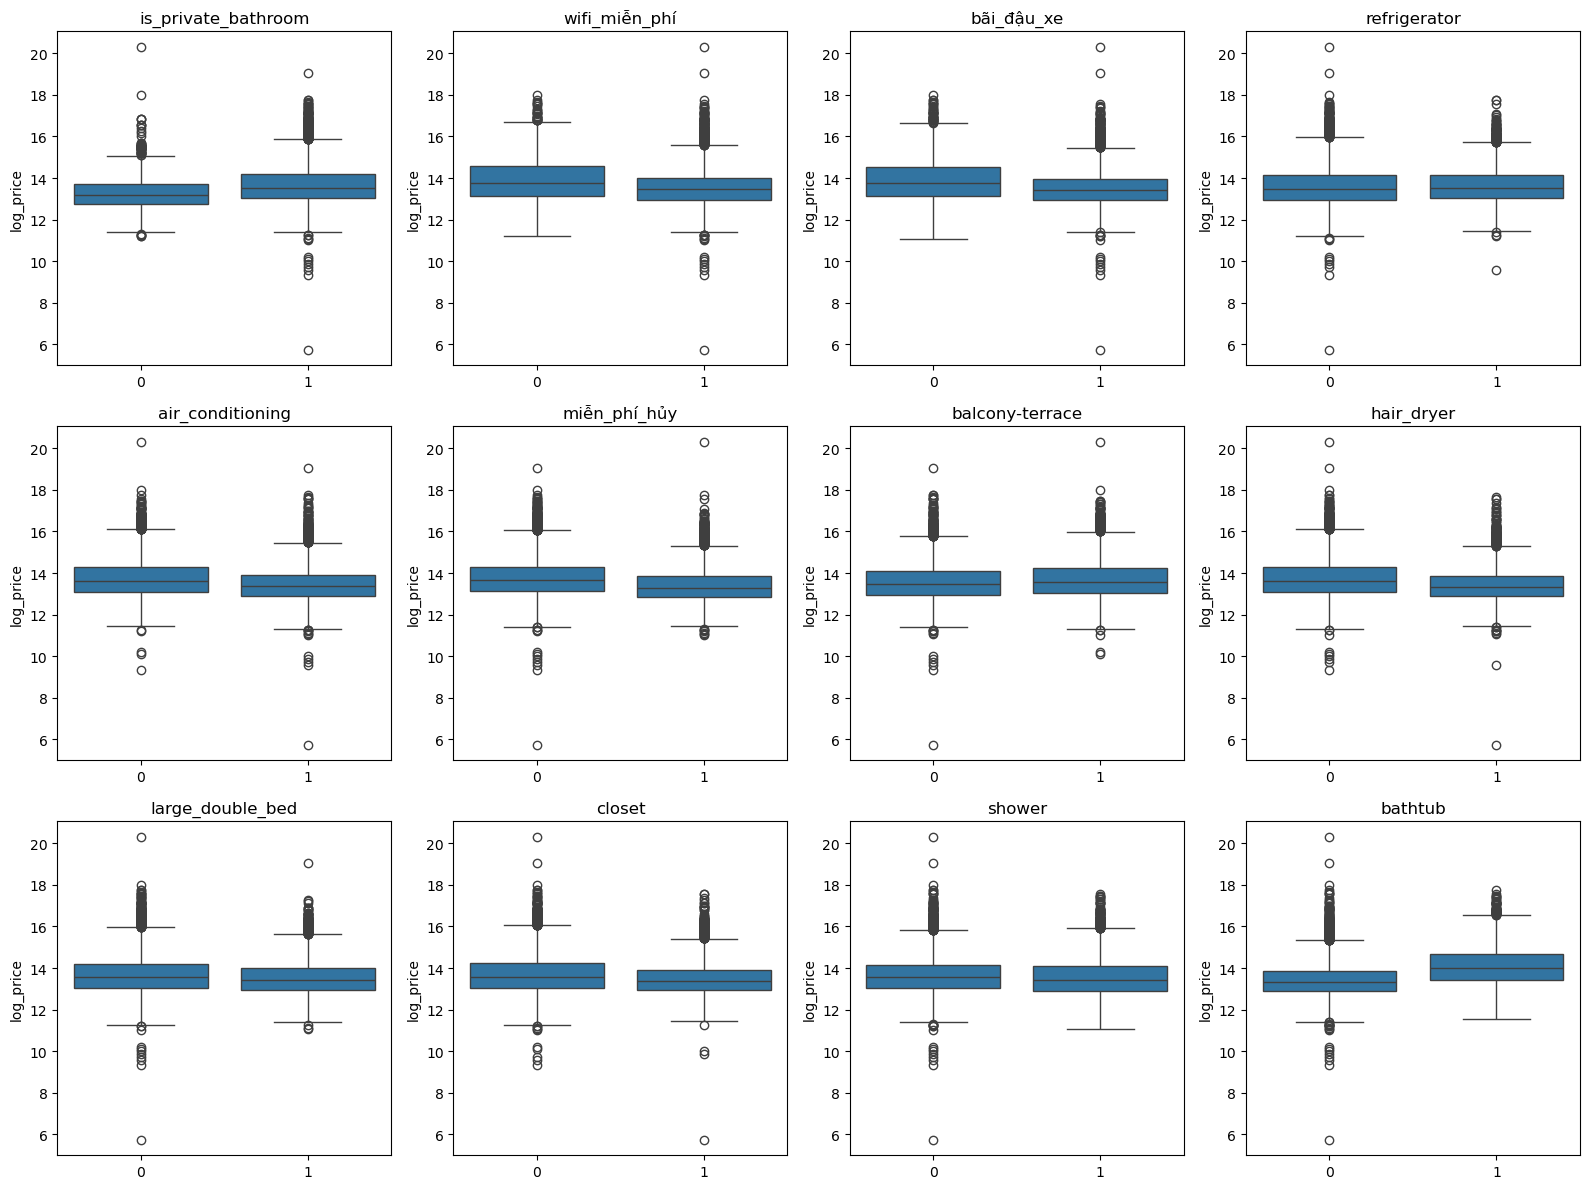

In [60]:
import math

bin_cols = [c for c in bin_col if c != "hotel_name"]
top_bin = df[bin_cols].sum().sort_values(ascending=False).head(12).index

n_cols = 4
n_rows = math.ceil(len(top_bin) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(top_bin):
    sns.boxplot(data=df, x=col, y="log_price", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("log_price")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**log_price vs Categorical & Binary Features (Summary)**

**`views` vs `log_price`**
Room view categories show noticeable differences in price distribution.  
Premium views (e.g., **sea / lake / pool**) tend to have slightly higher `log_price`, while **no_view** is generally cheaper and more variable.

**`region` (Top 15) vs `log_price`**
`log_price` varies across regions, suggesting **location is an important driver of price**.  
Some regions show higher typical prices and wider spreads, reflecting differences in tourism demand, hotel standards, and market conditions.

**`room_room_type_name` (Top 15) vs `log_price`**
Even among the Top 15 room types, price distributions differ clearly, indicating room type is strongly associated with price.  
However, each room type still has a wide spread and outliers, implying that room type alone cannot fully explain price without considering other factors (region, size, amenities).

**Binary amenities vs `log_price`**
Binary features generally show **moderate price separation** between rooms with the amenity (`1`) and without (`0`).  
Common amenities such as **private bathroom, WiFi, parking, refrigerator, air conditioning**, etc. may contribute to higher prices, but their effect is usually smaller than major factors like location and room size.


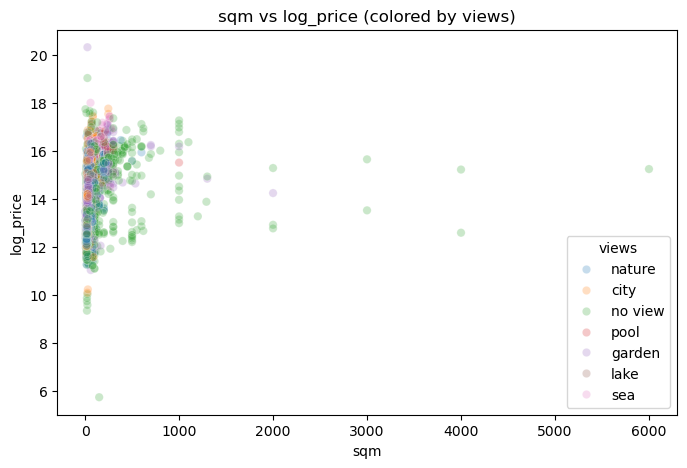

In [61]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="sqm", y="log_price", hue="views", alpha=0.25)
plt.title("sqm vs log_price (colored by views)")
plt.show()

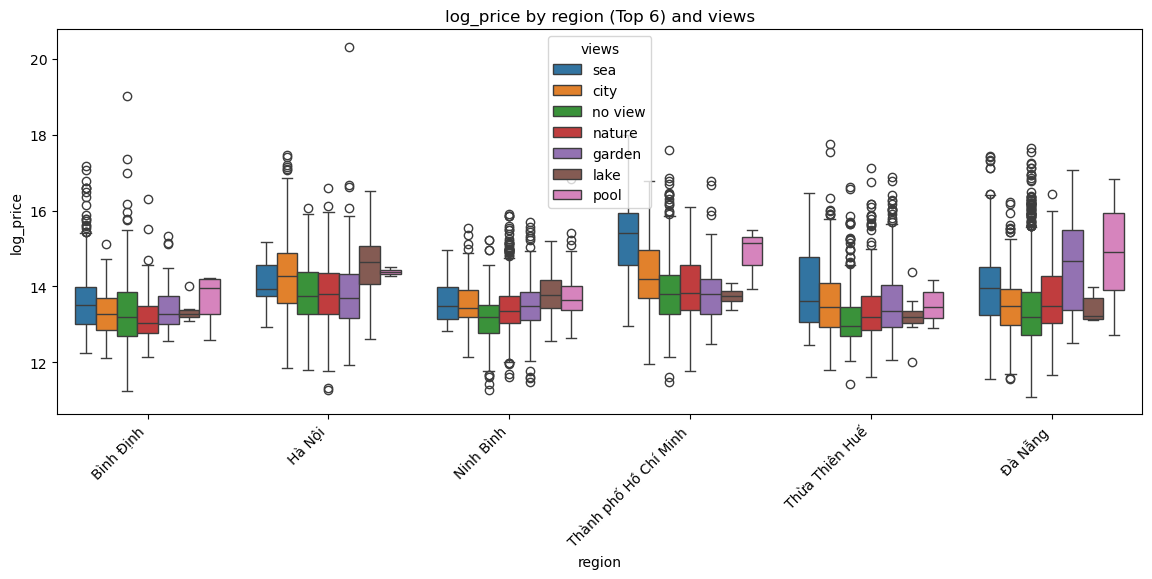

In [62]:
top6_regions = df["region"].value_counts().head(6).index
tmp = df[df["region"].isin(top6_regions)]

plt.figure(figsize=(14,5))
sns.boxplot(data=tmp, x="region", y="log_price", hue="views")
plt.title("log_price by region (Top 6) and views")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interaction Analysis: log_price with Multiple Features**

**`sqm` vs `log_price` colored by `views`**
The positive relationship between room size (`sqm`) and `log_price` remains visible across all view categories.  
Premium views (such as **sea, lake, pool**) tend to appear slightly higher on the price axis for similar room sizes, although the effect is weaker than that of room size itself.

**`log_price` by `region` (Top 6) and `views`**
Price distributions differ clearly across regions, confirming that **location is a major driver of price**.  
Within each region, view categories further differentiate prices, with premium views generally associated with higher `log_price`, though the magnitude of this effect varies by region.

Overall, these plots suggest that **price is influenced by interactions between size, location, and view**, rather than by any single factor alone.


## Modeling

### Linear Models (Linear/ Ridge/ Lasso)

### Tree base model (Random Forest/ XGBoost/ LightGBM/ CatBoost)